In [1]:
# Spectral analysis in PET

In [5]:
time_points=time=[3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
TAC_input=aorta=[124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
TAC=spleen=[38,190,516,1041,6547,14096,19961,24520,
    25196,30784,26850,23472,25687,28088,23546,20730,
    20538,17276,16126,13705,12283,11418,10745,10319]

In [3]:
import numpy as np # numerical functions
beta=np.arange(0, 1, 0.01)

In [6]:
from scipy import interpolate
interpolated_time_points=np.arange(3,266,1)
f=interpolate.interp1d(time_points,TAC)
TAC_interpolated=f(interpolated_time_points)
f=interpolate.interp1d(time_points,TAC_input)
TAC_input_interpolated=f(interpolated_time_points)

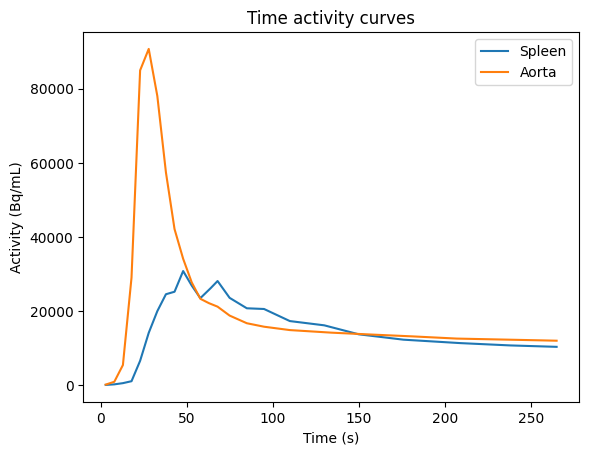

In [7]:
import matplotlib.pyplot as plt
plt.plot(interpolated_time_points,TAC_interpolated)
plt.plot(interpolated_time_points,TAC_input_interpolated)
plt.xlabel('Time (s)')
plt.ylabel('Activity (Bq/mL)')
plt.title('Time activity curves')
plt.legend(["Spleen","Aorta"])

In [8]:
# Define base function
# al=alpha (a numeric value)
# be=beta (a numeric value)
# time=time points (vector of numeric values; typically integers)
def base_function(al,be,time):
    return al*np.exp(-be*time)

# Define function for is convolution of a base function and input TAC
# al=alpha (a numeric value)
# be=beta (a numeric value)
# time=time points (vector of numeric values; typically integers)
# tac=time activity curve of input function with same length as time (vector of numeric values)
# NOTE: time and tac need to be of same length
def conv_comp(al,be,time,tac):
    return np.convolve(base_function(al,be,time),tac)

# Define operational function for spectral analysis
# al=alphas (a vector of non-negative numeric values)
# be=betas (a vector of non-negative numeric values)
# time=time points (vector of numeric values; typically integers)
# tac=time activity curve of input function with same length as time (vector of numeric values)
# NOTE: al and be need to be of same length; time and tac need to be of same length
def oper(al,be,time,tac):
    total_sum=0
    for k in range(len(al)):
        total_sum=total_sum+conv_comp(al[k],be[k],time,tac)
    return total_sum

In [11]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
from scipy.optimize import nnls
alpha=np.ones(len(beta)) # initial values for alphas; all ones
A=np.empty([len(interpolated_time_points),len(alpha)]) # create empty matrix for A
for k in range(len(beta)): # define A so that each column has one operational component
    A[:,k]=conv_comp(1,beta[k],interpolated_time_points,
    TAC_input_interpolated)[0:len(interpolated_time_points)]
b=TAC_interpolated # TAC of the organ to be modelled (spleen)
x,residuals=nnls(A,b) # Do non-negative linear least squares estimation

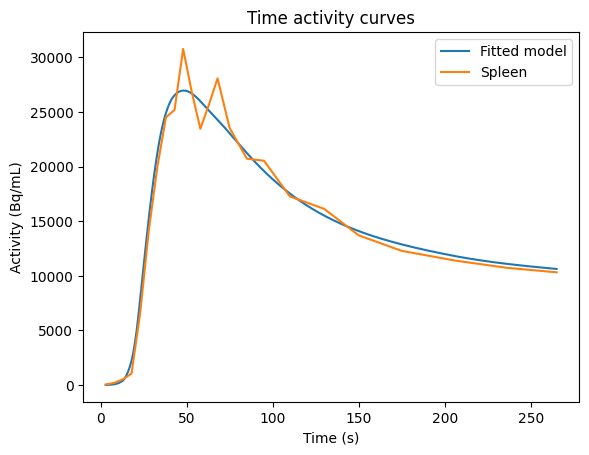

In [13]:
plt.plot(interpolated_time_points,oper(x,beta,interpolated_time_points,
TAC_input_interpolated)[0:len(interpolated_time_points)])
plt.plot(interpolated_time_points,TAC_interpolated)
plt.xlabel('Time (s)')
plt.ylabel('Activity (Bq/mL)')
plt.title('Time activity curves')
plt.legend(["Fitted model","Spleen"])